In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.append('../')
from src.features.features_engineering import feature_engineering

df = pd.read_csv("../data/raw/Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")
df_model = feature_engineering(df)
df_model.head()

,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,risk_score,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,customer_segment_Low Risk,...,age_group_Mayor,income_group_Medio,income_group_Alto,credit_group_Regular,credit_group_Bueno,credit_group_Excelente,dti_group_Medio,dti_group_Alto,purchase_group_Medio,purchase_group_Alto
0,9,0,0,0,449,0,True,False,False,True,...,True,False,False,False,False,True,False,False,False,False
1,12,0,0,0,492,0,True,False,False,True,...,True,False,False,False,False,True,False,False,False,False
2,6,0,0,0,698,0,True,False,False,True,...,True,False,False,False,False,True,False,False,False,False
3,9,0,0,0,537,0,True,False,False,True,...,False,False,False,False,False,True,False,False,False,False
4,6,0,0,0,973,0,True,False,False,True,...,False,False,False,False,False,True,False,False,False,False


En primer lugar vamos a crear una copia del dataframe original para hacerle nuestras modificaciones y preservar los datos originales.

In [8]:
df_clean = df.copy()

#### Eliminar columnas sin informacion relevantes

Borraremos 'user_Id' y 'transaction_date', que son un identificadores, y por otro lado las variables de 'product_category' y 'location', que no tendrán importancia en la creación de los modelos, como lo habíamos dicho en nuestro análisis exploratorio en la fase de comprensión de los datos.

In [9]:
df_clean = df_clean.drop(columns=['user_id','product_category','location','transaction_date'])

### Categorización de variables numericas

In [10]:
# Creamos grupos categóricos a partir de variables numéricas clave

df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[18, 25, 35, 50, 60],
    labels=['Joven', 'Joven_Adulto', 'Adulto', 'Mayor']
)

# Grupo de ingreso mensual
df_clean['income_group'] = pd.cut(
    df_clean['monthly_income'],
    bins=[0, 20000, 50000, 100000],
    labels=['Bajo', 'Medio', 'Alto']
)

# Grupo de credit score
df_clean['credit_group'] = pd.cut(
    df_clean['credit_score'],
    bins=[300, 580, 670, 740, 850],
    labels=['Malo', 'Regular', 'Bueno', 'Excelente']
)

# Grupo de debt-to-income
df_clean['dti_group'] = pd.cut(
    df_clean['debt_to_income_ratio'],
    bins=[0, 0.2, 0.4, 1],
    labels=['Bajo', 'Medio', 'Alto']
)

# Grupo de monto de compra
df_clean['purchase_group'] = pd.cut(
    df_clean['purchase_amount'],
    bins=[0, 1000, 5000, 20000],
    labels=['Bajo', 'Medio', 'Alto']
)

# Eliminamos las antiguas

df_clean.drop(columns=['age', 'monthly_income', 'credit_score', 'debt_to_income_ratio', 'purchase_amount'], inplace=True)




#### Dummies

Debido a que no podemos usar categorías para entrenar los modelos de Machine Learning, debemos crear dummies para cada categoría en columnas binarias (0 o 1), así evitando que el modelo piense que hay órdenes o jerarquía entre categorías; permite al modelo capturar el efecto de cada grupo que hay.

In [11]:

df_model = pd.get_dummies(df_clean, drop_first=True)


print("Shape final:", df_model.shape)
print("\nColumnas:")
print(df_model.columns)

Shape final: (9528, 23)

Columnas:
Index(['bnpl_installments', 'repayment_delay_days', 'missed_payments',
       'default_flag', 'app_usage_frequency', 'risk_score',
       'employment_type_Self-Employed', 'employment_type_Student',
       'employment_type_Unemployed', 'customer_segment_Low Risk',
       'customer_segment_Medium Risk', 'age_group_Joven_Adulto',
       'age_group_Adulto', 'age_group_Mayor', 'income_group_Medio',
       'income_group_Alto', 'credit_group_Regular', 'credit_group_Bueno',
       'credit_group_Excelente', 'dti_group_Medio', 'dti_group_Alto',
       'purchase_group_Medio', 'purchase_group_Alto'],
      dtype='object')


#### Mapa de calor con las variables numericas y categoricas

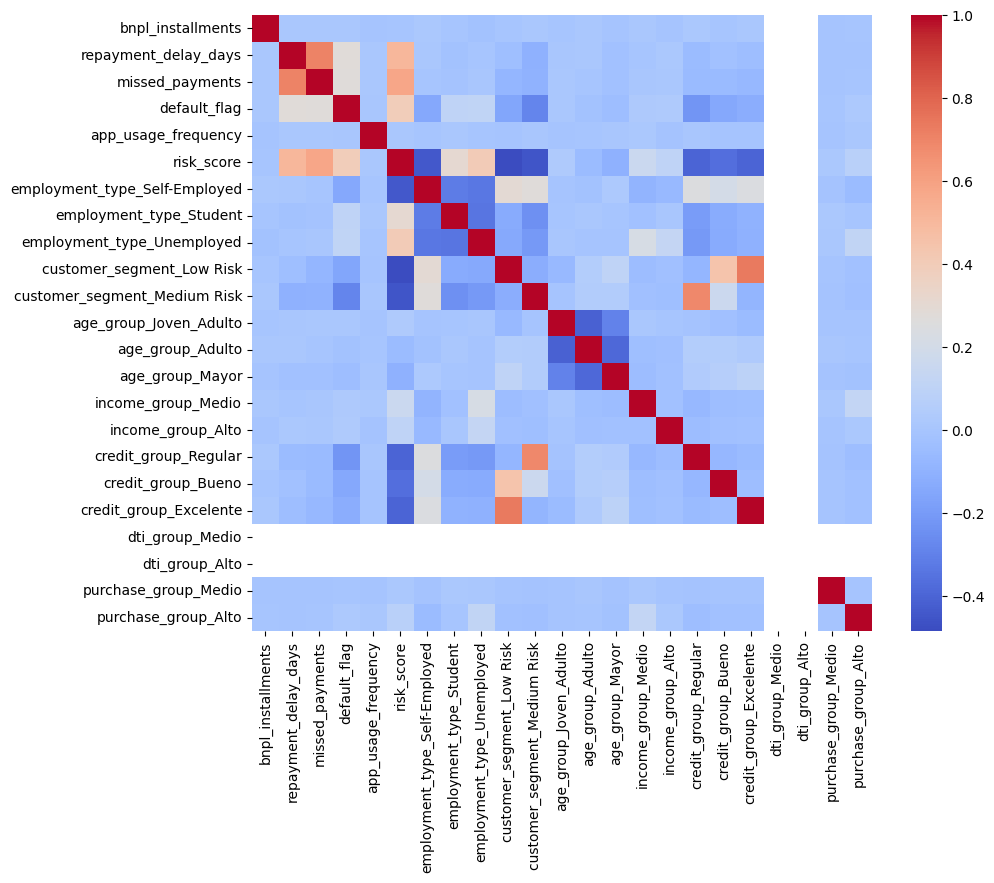

default_flag                     1.000000
risk_score                       0.391424
repayment_delay_days             0.279139
missed_payments                  0.270351
employment_type_Unemployed       0.109028
employment_type_Student          0.105868
income_group_Alto                0.032742
income_group_Medio               0.025910
purchase_group_Alto              0.023002
bnpl_installments                0.013474
age_group_Joven_Adulto           0.009289
app_usage_frequency              0.004265
purchase_group_Medio             0.001447
age_group_Adulto                -0.018422
age_group_Mayor                 -0.044184
credit_group_Excelente          -0.122247
credit_group_Bueno              -0.144640
employment_type_Self-Employed   -0.146947
customer_segment_Low Risk       -0.159950
credit_group_Regular            -0.229877
customer_segment_Medium Risk    -0.286437
dti_group_Medio                       NaN
dti_group_Alto                        NaN
Name: default_flag, dtype: float64

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df_model.corr(), cmap='coolwarm')
plt.show()

corr = df_model.corr()['default_flag'].sort_values(ascending=False)
print(corr)


En la parte de modelado decidimos seleccionar 3 conjuntos de variables para hacer un análisis de cómo cambiarán sus métricas y entrenamientos. Está más detallado en el siguiente notebook.